# Recinos Topic Model

In [2]:
import pandas as pd
import numpy as np

In [3]:
from sklearn.decomposition import NMF

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
sns.set()

# Get Data

In [6]:
OHCO = ['parte','capit','sent','token']

In [7]:
DOC = pd.read_csv("recinos-DOC.csv").set_index(OHCO[:2])
VOCAB = pd.read_csv("recinos-VOCABX.csv").set_index('term_str')

In [8]:
TOKEN = pd.read_csv("recinos-TOKEN.csv").set_index(OHCO)
DTM = TOKEN[TOKEN.token_pos.isin(['NOUN','PROPN','VERB'])].groupby(OHCO[:2]+['term_str']).term_str.count().unstack(fill_value=0)

In [9]:
STOP = VOCAB[VOCAB.stop == True].index
DTM = DTM[list(set(DTM.columns) - set(STOP))]

# Compute NMF

In [10]:
n_topics = 5
nmf_engine = NMF(n_components=n_topics, max_iter=1000)

## THETA

In [11]:
# NMF?

In [12]:
THETA = pd.DataFrame(nmf_engine.fit_transform(DTM), index=DTM.index)

## PHI

In [13]:
PHI = pd.DataFrame(nmf_engine.components_, columns=DTM.columns)

## Topics

In [14]:
n_terms = 3
TOPIC = PHI.T.apply(lambda x: ', '.join(x.sort_values(ascending=False).head(n_terms).index)).T.to_frame('top_terms')

In [15]:
TOPIC

,top_terms
0,"xibalba, muchachos, senores"
1,"tohil, tribus, mahucutah"
2,"abuela, ixbalanque, hunahpu"
3,"senores, casa, generacion"
4,"tierra, cielo, hombre"


In [16]:
PHIN = PHI + .01

PW = PHIN.sum() / PHIN.sum().sum()
PTw = (PHIN / PHIN.sum()).T
PT = (PHIN.T.sum() / PHIN.T.sum().sum())
PHI_DST = PTw * np.log(PTw/PT)
PHI_SAL = PHI_DST.T * PW
TOPIC['top_sal'] = PHI_SAL.T.apply(lambda x: ', '.join(x.sort_values(ascending=False).head(n_terms).index)).T

λ = .5
PHI_REL = λ * np.log(PHIN) + (1 - λ) * np.log(PHIN/PW)
TOPIC['top_rel'] = PHI_REL.T.apply(lambda x: ', '.join(x.sort_values(ascending=False).head(n_terms).index)).T

In [17]:
TOPIC

,top_terms,top_sal,top_rel
0,"xibalba, muchachos, senores","xibalba, muchachos, pelota","xibalba, muchachos, mensajeros"
1,"tohil, tribus, mahucutah","tohil, tribus, mahucutah","tohil, tribus, mahucutah"
2,"abuela, ixbalanque, hunahpu","abuela, hermanos, hunchouen","abuela, hermanos, hunchouen"
3,"senores, casa, generacion","senores, generacion, casa","generacion, senores, reyes"
4,"tierra, cielo, hombre","tierra, cielo, hombre","tierra, cielo, creador"


# View Topics over Narrative Time

In [18]:
# topic_order = [4,5,0,2,1,3]

In [19]:
THETA.columns = TOPIC.top_sal

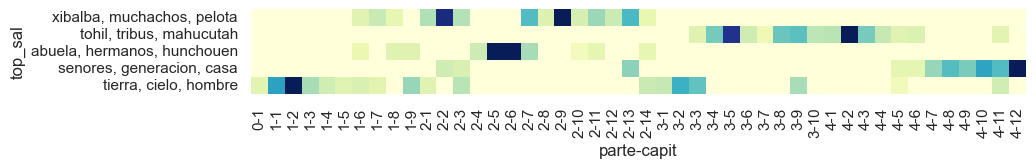

In [20]:
fig, ax = plt.subplots(figsize=(10, 15))
sns.heatmap(THETA[THETA > .3].fillna(0).T, cmap="YlGnBu", robust=True, square=True, cbar=False, ax=ax)
plt.show()

# Cluster Docs by Topics

In [21]:
import sys
sys.path.append("../../local_lib/")

In [22]:
from hac2 import HAC

In [23]:
metric = 'euclidean' # "euclidean", "l1", "l2", "manhattan", "cosine", or "precomputed"
linkage = 'ward' # 'ward', 'complete', 'average', 'single'

In [24]:
fig1 = HAC(THETA)
fig1.linkage_method = linkage
fig1.dist_metric = metric

In [25]:
# fig1.color_thresh = 2.5 # w/o verbs
# fig1.color_thresh = 1 
fig1.color_thresh = 2

<Figure size 640x480 with 0 Axes>

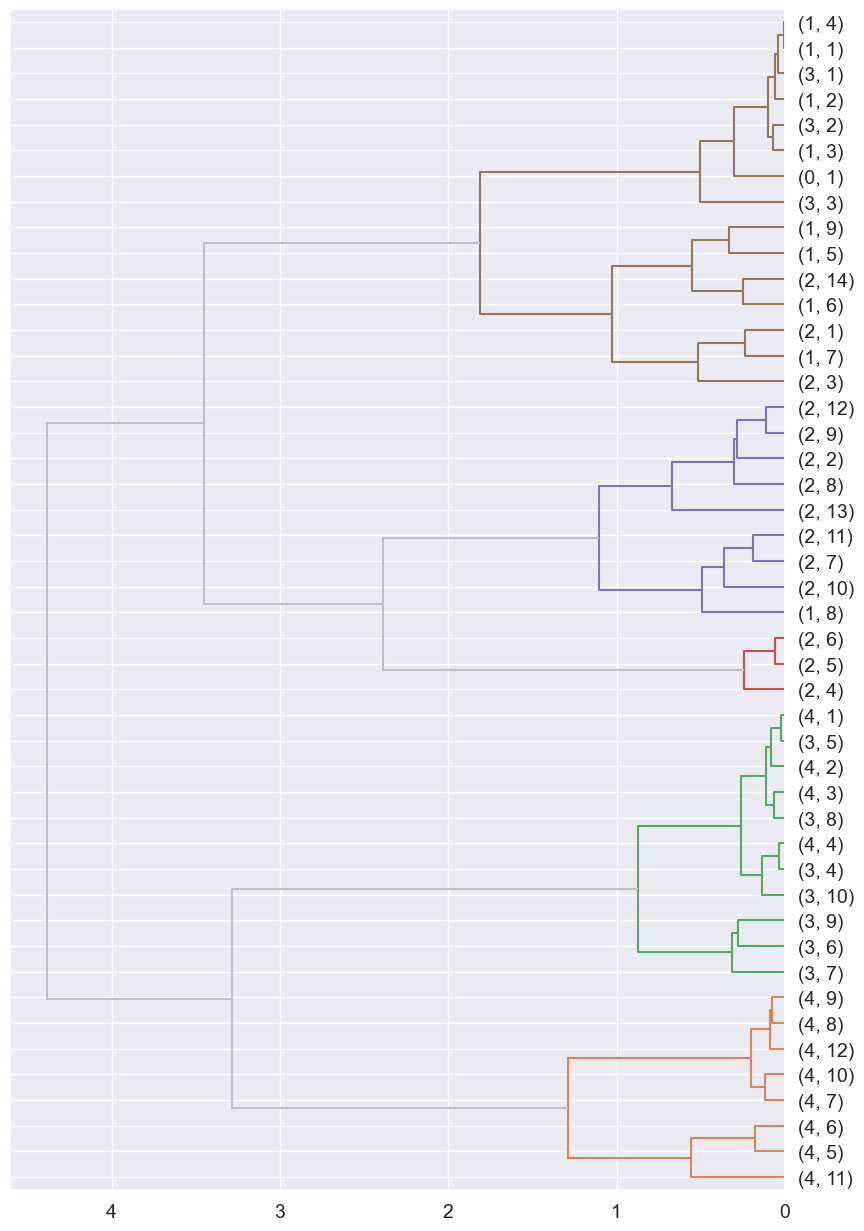

In [26]:
fig1.plot()

In [27]:
label_color = {
    '1': 'orange',
    '2': 'limegreen',
    '3': 'red',
    '4': 'violet',
    '5': 'tan',
    '6': 'orange',
    '7': 'purple',
    '8': 'fuscha',
    '9': 'limegreen',
    '': 'white'
}

In [28]:
fig1.get_cluster_labels()
DOC['topic_group'] = fig1.CLUSTER_LABELS
DOC.topic_group = DOC.topic_group.astype(str)

In [29]:
DOC.topic_group.unstack(fill_value='')\
    .style.applymap(lambda x: 'background:' + label_color[x])

capit,1,2,3,4,5,6,7,8,9,10,11,12,13,14
parte,,,,,,,,,,,,,,
0,3,,,,,,,,,,,,,
1,3,3,3,3,3,3,3,5,3,,,,,
2,3,5,3,4,4,4,5,5,5,5,5,5,5,3
3,3,3,3,1,1,1,1,1,1,1,,,,
4,1,1,1,1,2,2,2,2,2,2,2,2,,


# Compare to HAC clusters

In [30]:
DOC.value_counts(['label','topic_group']).unstack(fill_value=0).style.background_gradient(cmap="YlGnBu", axis=None)

topic_group,1,2,3,4,5
label,,,,,
1,0,0,3,3,8
2,0,0,5,0,0
3,0,0,5,0,1
4,0,6,0,0,0
5,11,2,2,0,0


In [31]:
DOC[['label','topic_group']].corr('spearman').iloc[0,1]

-0.8766917558116754

# Correlate Documents in Topic Space

In [82]:
# fig, ax = plt.subplots(figsize=(12, 10))
# sns.heatmap(THETA.T.corr(), cmap='Spectral', xticklabels=True, yticklabels=True, ax=ax)
# plt.show()

In [33]:
import plotly_express as px

In [38]:
X = THETA.T.corr()

In [74]:
labels = [str(x[0]).zfill(2) + ':' + str(x[1]).zfill(2) for x in X.index.values]

In [81]:
# px.colors.diverging.Spectral

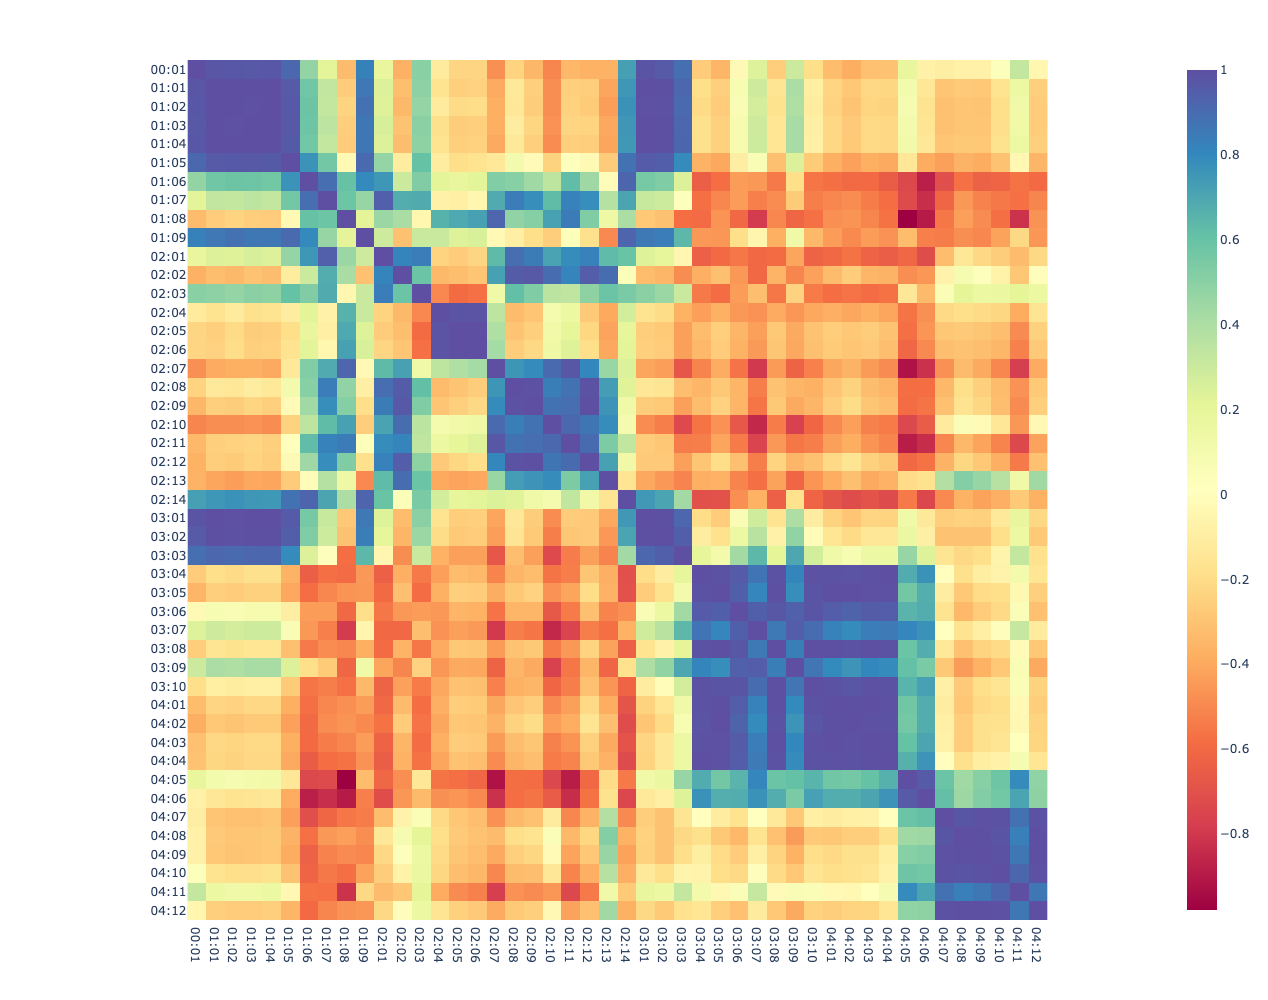

In [79]:
px.imshow(X.values, x = labels,y = labels,
        height=1000, width=1200,
        color_continuous_scale=px.colors.diverging.Spectral)

<Axes: xlabel='parte,capit'>

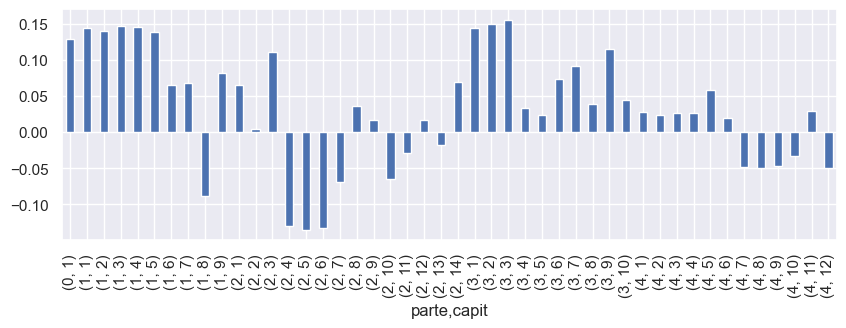

In [73]:
X.mean().plot.bar(figsize=(10,3))

# Correlate Topics in Word Space

In [139]:
# sns.heatmap(PHI.T.corr(), cmap='YlGnBu')

In [140]:
PHI.T.corr().style.background_gradient(cmap="YlGnBu")

,0,1,2,3,4
0,1.000000,0.092378,0.262296,0.234515,0.080797
1,0.092378,1.000000,0.061527,0.140293,0.115582
2,0.262296,0.061527,1.000000,0.080519,0.150059
3,0.234515,0.140293,0.080519,1.000000,0.084546
4,0.080797,0.115582,0.150059,0.084546,1.000000


In [141]:
TOPIC

,top_terms,top_sal,top_rel
0,"xibalba, muchachos, senores","xibalba, muchachos, pelota","xibalba, muchachos, mensajeros"
1,"tohil, tribus, mahucutah","tohil, tribus, mahucutah","tohil, tribus, mahucutah"
2,"abuela, ixbalanque, hunahpu","abuela, hermanos, hunchouen","abuela, hermanos, hunchouen"
3,"senores, casa, generacion","senores, generacion, casa","generacion, senores, reyes"
4,"tierra, cielo, hombre","tierra, cielo, hombre","tierra, cielo, creador"


In [142]:
R = PHI.T.corr().stack().to_frame('r')
R.index.names = ['topic_a', 'topic_b']
R = R.query("topic_a < topic_b")

In [143]:
# R.sort_values('r', ascending=False).style.bar(color='violet')

In [144]:
R2 = pd.concat([R.reset_index(), 
           R.reset_index().topic_a.map(TOPIC.top_sal).to_frame('a_terms'), 
           R.reset_index().topic_b.map(TOPIC.top_sal).to_frame('b_terms')], axis=1)\
    .set_index(['topic_a','topic_b']).sort_values('r', ascending=False)

In [145]:
R2.style.bar(color='violet')